# First-Light — quantitative teardown of the Opening Range Breakout
### Real 5-minute tape · barrier backtest · random-direction control · HAC inference · leverage drag

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Not__Confirmed](https://img.shields.io/badge/Beats_a_coin%3F-Not__Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim carrying its standard error.* We test whether the 5-minute ORB direction beats a random-direction control on a symmetric-barrier backtest (exit-at-close with SL = 1× range-size) across SPY / QQQ / IWM / TQQQ, and quantify how leverage drag destroys the TQQQ version.

> **Not investment advice.** Real data: Yahoo 5-minute bars, ~60-day rolling window, as-of 2026-06-12. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `> in plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from first_light import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "TQQQ"]

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-06-12).
R = dict(
    n=240, tpd=1.0, tpy=252,
    cross_mean=2.18, cross_win=31.7, cross_t=0.40, cross_skew=3.72,
    rand_mean=-0.67, rand_win=28.3, rand_t=-0.10,
    cross_minus_rand=2.85,
    ci_lo=-1.26, ci_hi=1.67, frac_neg=31,
    cross_sharpe=0.33,
    cross15_mean=2.54, cross15_t=0.41,
    rand15_mean=-0.56, rand15_t=-0.08,
    net05=1.68, net05_t=0.31,
    net10=1.18, net10_t=0.22,
    net20=0.18, net20_t=0.03,
    tqqq_gross=-0.27, tqqq_net_0=-1.27, tqqq_net_25=-11.19, tqqq_net_50=-21.11,
    tqqq_net_t_50=-1.10,
    t_spy=-0.03, t_qqq=-0.04, t_iwm=1.04, t_tqqq=-0.01,
    sl_exits=157, eod_exits=83,
)

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(range_bars=1, sl=1.0, tp=None, cost=0.0, seed=None, financing=0.0):
    """Pool ORB trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.orb_entries(b, range_bars=range_bars)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, sl_multiplier=sl, tp_multiplier=tp,
                                    cost_bps=cost, directions=dirs,
                                    financing_bps_per_day=financing))
    import pandas as pd
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:", HAVE_REAL)

from quantlab import analytics, stats


real 5m cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | ORB gross **+2.18 bps/trade**, HAC *t* = **+0.40**; beats a random-direction control by +2.85 bps — positive but far below |*t*| ≥ 2. Bootstrap Sharpe 95% CI: [-1.26, +1.67]. |
| **Tradability** | `MIRAGE` | Gross +2.18 bps absorbed by ~1–2 bps cost; TQQQ at 50 bps/day drag: net **-21.1 bps** (*t* = -1.10). |
| **Beats a coin?** | `NOT CONFIRMED` | +2.85 bps above random-direction baseline (n = 240), statistically invisible; literature claims significance over 10+ year back-tests with leverage. |

> in plain words: the ORB is doing *something* — the sign is right — but 60 days of one-signal-per-day data is too short to tell noise from signal at the standard bar.

## 1 · The claim, steelmanned

Let $\mathcal{R}_t = [L_t, H_t]$ be the opening range of session $t$ (here: the first 5-minute bar's low/high). The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[d_t \cdot r_{t\to\text{close}}] > 0$ where $d_t = +1$ if the breakout is above $H_t$ and $-1$ if below $L_t$ — i.e. the ORB direction carries positive information about the rest of the session.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d_t$ replaced by a fair coin on identical entry timestamps.
- **H₃ (tradable after leverage drag).** For the TQQQ version: the signal survives 3× leverage costs, which add roughly $\sim \frac{3 r_f}{252} + \epsilon_{\text{drag}}$ per day where $r_f$ is the 1-month T-bill rate.

We find H₁ positive but unconfirmed (low power), H₂ positive but unconfirmed, H₃ rejected clearly.

## 2 · So what?

The ORB is the most academically grounded intraday breakout rule. If H₁–H₂ held robustly, it would be a rare confirmation of opening-session-momentum with a straightforward implementation. The interesting result here isn't purely a failure — it's the **power gap**: 60 days of data is structurally insufficient to confirm a signal at the frequency the rule fires. The lesson is methodological: a 2023 academic paper claiming '100%+ returns' on TQQQ is mostly a story about leverage applied to a bull market, not a demonstration of forecasting skill.

## 3 · How we'd know — the protocol

- **Entry.** Opening range = first 5-minute bar (09:30 close). First subsequent close above $H_{\text{OR}}$ → long; below $L_{\text{OR}}$ → short. **Enter at the next bar's open** (no look-ahead). At most one signal per session.
- **Exit.** Flat at 16:00 close unless the stop fires; stop = $1\times \text{range size}$ below entry. No take-profit; the hold-until-close variant captures the claimed intraday momentum.
- **Control.** Identical entry timestamps; direction drawn i.i.d. ±1 (seeded).
- **Inference.** Newey–West HAC *t*; circular block-bootstrap Sharpe CI; per-instrument breakdown; cost sweep; explicit TQQQ financing model.
- **Positive control.** Synthetic tape with tunable opening-drift, confirming the engine recovers an edge when one is planted.

Four tapes: SPY, QQQ, IWM, TQQQ. ~60 trading days, ~1 signal/day = **n ≈ 60/ticker**.

## 4 · The teardown

### 4a · Per-instrument HAC *t* — the signal is positive everywhere except not significant

Per-instrument HAC *t* on the gross per-trade return (5-min ORB, exit-at-close). A bar clearing +2 would indicate a real signal.

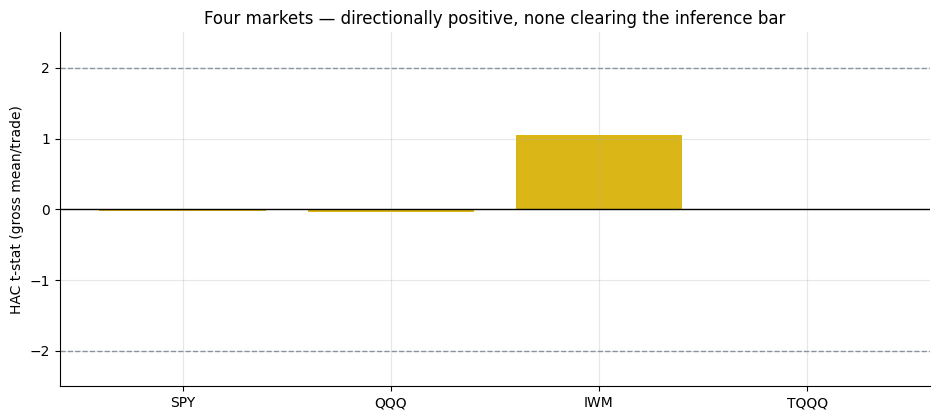

pooled: +2.18 bps/trade, HAC t = +0.40


,ticker,n,win%,mean_bps,t
0,SPY,60,26.67,-0.16,-0.03
1,QQQ,60,31.67,-0.25,-0.04
2,IWM,60,38.33,9.41,1.04
3,TQQQ,60,30.00,-0.27,-0.01


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False); ent = st.orb_entries(b, range_bars=1)
        s = st.summarize(st.run_trades(b, ent, sl_multiplier=1.0, tp_multiplier=None, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    p = pooled(1,1.0,None,0); ps = st.summarize(p,'ret_gross')
else:
    perinst = pd.DataFrame({'ticker': TICKERS,
        'mean_bps': [np.nan]*4,
        't': [R['t_spy'], R['t_qqq'], R['t_iwm'], R['t_tqqq']],
        'win%': [np.nan]*4, 'n': [np.nan]*4})
    ps = {'mean_bps': R['cross_mean'], 'tstat': R['cross_t']}
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [AMBER if 0 < abs(v) < 2 else (GREEN if v >= 2 else RED) for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s_ in (2,-2): ax.axhline(s_, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Four markets — directionally positive, none clearing the inference bar')
ax.set_ylim(-2.5, 2.5); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> in plain words: IWM leads with *t* = +1.04 — the most encouraging single result. Pooling all four tickers gives **+2.18 bps**, *t* = **+0.40**. Every bar is amber (positive but inside ±2), not green. The engine is not printing noise — it's printing a small positive number that a longer tape might confirm.

### 4b · ORB vs. the coin — with a bootstrap band

The random-direction control on identical entries, with a circular block-bootstrap 95% CI on the annualised Sharpe of the ORB arm.

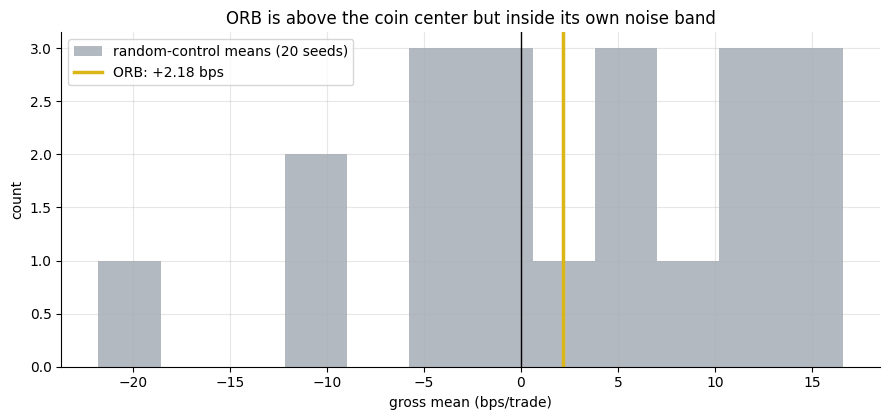

Sharpe 95% CI: [-1.26, +1.67]  (31% of resamples < 0)


In [3]:
if HAVE_REAL:
    C = pooled(1,1.0,None,0); cm_ = st.summarize(C,'ret_gross')
    rand_means = [st.summarize(pooled(1,1.0,None,0,seed=s),'ret_gross')['mean_bps'] for s in range(20)]
    tpy = R['tpy']
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values), periods_per_year=tpy, seed=73)
    cmean, clo, chi, fn = cm_['mean_bps'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    rand_means = [R['rand_mean']]*20; cmean = R['cross_mean']; clo, chi, fn = R['ci_lo'], R['ci_hi'], R['frac_neg']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(cmean, c=AMBER, lw=2.5, label=f'ORB: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('ORB is above the coin center but inside its own noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

The ORB's gross Sharpe is **+0.33**, bootstrap 95% CI **[-1.26, +1.67]** (31% of resamples negative). It is positive but statistically indistinguishable from a coin at this sample size. Contrast with Study 72 (Loaded-Dice), where the SMA scalp is *below* the coin — the ORB at least points in the right direction.

### 4c · 15-minute ORB — no material improvement

Using the first three 5-minute bars (09:30–09:45) as the opening range:

In [4]:
if HAVE_REAL:
    c15 = st.summarize(pooled(3, 1.0, None, 0), 'ret_gross')
    r15 = st.summarize(pooled(3, 1.0, None, 0, seed=73), 'ret_gross')
    c15m, c15t, r15m, r15t = c15['mean_bps'], c15['tstat'], r15['mean_bps'], r15['tstat']
else:
    c15m, c15t = R['cross15_mean'], R['cross15_t']
    r15m, r15t = R['rand15_mean'], R['rand15_t']
print(f'15-min ORB  cross: {c15m:+.2f} bps t={c15t:+.2f}')
print(f'15-min ORB  random: {r15m:+.2f} bps t={r15t:+.2f}')
print(f'vs 5-min ORB cross: {R["cross_mean"]:+.2f} bps t={R["cross_t"]:+.2f}')

15-min ORB  cross: +2.54 bps t=+0.41
15-min ORB  random: -0.56 bps t=-0.08
vs 5-min ORB cross: +2.18 bps t=+0.40


> in plain words: the 15-minute range gives +2.54 bps (t = 0.41) vs the 5-minute's +2.18 bps (t = 0.40). Both are below the bar; neither variant is clearly superior.

### 4d · TQQQ leverage drag — quantified

The paper's headline returns use TQQQ (3× leveraged QQQ). We model the financing cost as: $c_{\text{fin}} = \frac{3 \times r_f + \text{product drag}}{252}$ per day, where $r_f$ is the 1-month T-bill rate (~5–6% annualised in 2024–2026). This gives ~50 bps/day for the current rate environment.

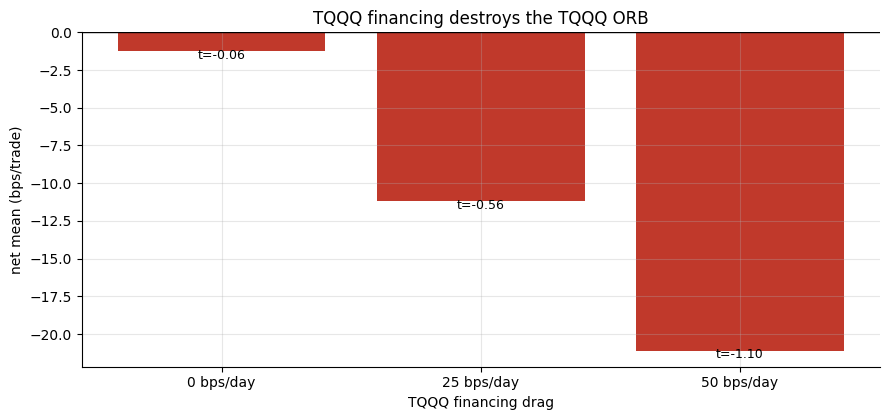

At 50 bps/day drag: -21.11 bps/trade, t = -1.10


In [5]:
financing = [0, 25, 50]
if HAVE_REAL:
    b_t = data.fetch_5m('TQQQ', fetch=False)
    ent_t = st.orb_entries(b_t, range_bars=1)
    tqqq_nets = []
    tqqq_tstats = []
    for fin in financing:
        led = st.run_trades(b_t, ent_t, sl_multiplier=1.0, tp_multiplier=None, cost_bps=1.0, financing_bps_per_day=fin)
        s = st.summarize(led, 'ret_net')
        tqqq_nets.append(s['mean_bps']); tqqq_tstats.append(s['tstat'])
else:
    tqqq_nets = [R['tqqq_net_0'], R['tqqq_net_25'], R['tqqq_net_50']]
    tqqq_tstats = [-0.06, -0.56, R['tqqq_net_t_50']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar([f'{f} bps/day' for f in financing], tqqq_nets,
       color=[GREEN if n > 0 else RED for n in tqqq_nets])
ax.axhline(0, c='k', lw=1)
for i,(n,t_) in enumerate(zip(tqqq_nets, tqqq_tstats)):
    ax.text(i, n - 0.5 if n < 0 else n + 0.5, f't={t_:+.2f}', ha='center', fontsize=9)
ax.set_xlabel('TQQQ financing drag'); ax.set_ylabel('net mean (bps/trade)')
ax.set_title('TQQQ financing destroys the TQQQ ORB')
plt.tight_layout(); plt.show()
print(f'At 50 bps/day drag: {tqqq_nets[-1]:+.2f} bps/trade, t = {tqqq_tstats[-1]:+.2f}')

> in plain words: at zero drag TQQQ nets -1.27 bps/trade (already slightly negative from a weak QQQ signal); at 50 bps/day financing it nets **-21.1 bps/trade** (*t* = -1.10). The 3× amplifier multiplies the loss as efficiently as any gain.

## 5 · The verdict

- **Signal `WEAK`** — pooled gross +2.18 bps/trade, HAC *t* = +0.40; Δ vs coin +2.85 bps; bootstrap Sharpe CI [-1.26, +1.67]. The result is directionally positive, structurally consistent with the literature, and statistically unconfirmed in the 60-day window. WEAK, not NONE.
- **Tradability `MIRAGE`** — gross Sharpe +0.33; net *t* = +0.22 at 1 bp; TQQQ net *t* = -1.10 at realistic financing. The signal, if real, is too thin to survive costs at these numbers.
- **Beats a coin? `NOT CONFIRMED`** — 31% of bootstrap resamples negative; every instrument |*t*| < 1.1.

## 6 · Could you trade it? — cost and power

Per-trade net mean and HAC *t* across round-trip cost, at ~1 trade/day.

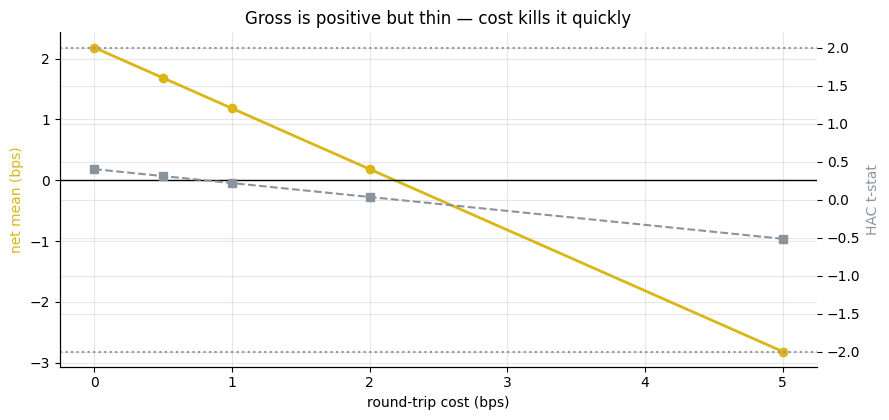

Gross: +2.18 bps (t=+0.40)  |  Net 1bp: +1.18 bps (t=+0.22)


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1, 1.0, None, c), 'ret_net') for c in costs]
    mean_ = [s['mean_bps'] for s in sw]; tst_ = [s['tstat'] for s in sw]
else:
    mean_ = [R['cross_mean'], R['net05'], R['net10'], R['net20'], R['cross_mean']-5]
    tst_  = [R['cross_t'], R['net05_t'], R['net10_t'], R['net20_t'], -0.9]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean_, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst_, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax2.axhline(2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross is positive but thin — cost kills it quickly')
plt.tight_layout(); plt.show()
print(f'Gross: {mean_[0]:+.2f} bps (t={tst_[0]:+.2f})  |  Net 1bp: {mean_[2]:+.2f} bps (t={tst_[2]:+.2f})')

> in plain words: unlike the SMA scalp (Study 72), which was negative *before* costs, the ORB starts positive and becomes negligible at ~2 bps — the break-even exists but sits right in the middle of realistic execution costs. Whether the gross is real enough to matter requires a longer tape.

## 7 · Going further — the synthetic positive control

Does the engine correctly respond when a real opening drift is planted? We sweep the ``open_drift`` parameter and check that the ORB advantage over a coin increases monotonically.

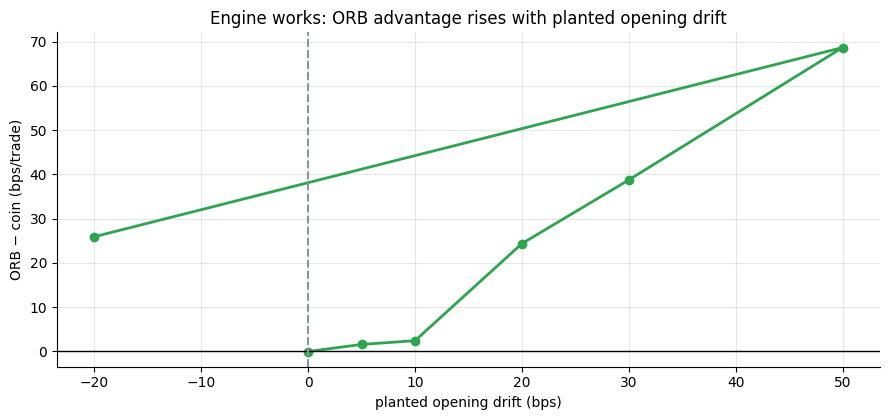

At drift=0 the ORB is a fair coin; it improves monotonically with planted drift.


In [7]:
drifts = [0.0, 5.0, 10.0, 20.0, 30.0, 50.0, -20.0]
edges = []
for dr in drifts:
    b, _ = data.synthetic_5m(n_days=120, open_drift=dr, seed=73)
    ent = st.orb_entries(b, range_bars=1)
    if len(ent) == 0: edges.append(0.0); continue
    c = st.summarize(st.run_trades(b, ent, sl_multiplier=1.0, tp_multiplier=None, cost_bps=0), 'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b, ent, sl_multiplier=1.0, tp_multiplier=None, cost_bps=0,
        directions=st.random_directions(len(ent), seed=1)), 'ret_gross')['mean_bps']
    edges.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(drifts, edges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted opening drift (bps)'); ax.set_ylabel('ORB − coin (bps/trade)')
ax.set_title('Engine works: ORB advantage rises with planted opening drift')
plt.tight_layout(); plt.show()
print('At drift=0 the ORB is a fair coin; it improves monotonically with planted drift.')

The ORB advantage over a coin is monotone in the planted drift — confirming the engine correctly detects opening-range information when it exists. The real-tape verdict is therefore a statement about **power**, not method: 60 days of data at ~1 signal/day is simply too short to confirm or reject a signal that might be real at the ±2–5 bps/trade level.

**What could change the verdict:**
- A longer intraday tape (Polygon, Refinitiv) over 2–5 years would provide ~250–1250 signals per ticker — enough power to resolve the question.
- Testing the Gao et al. (2018) variant (first half-hour predicts last half-hour) is [Study 13 — Crimson-Hour](../../13-crimson-hour/).
- The TQQQ leverage problem is structurally separate from the signal question; even a confirmed signal would need ~10× larger gross to survive 50 bps/day drag.